# 05 — Model Comparison
### Forecasting model comparison - LSTM vs GRU vs TFT
> Run notebooks 01, 02, and 03 first.


In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load all forecasting results
results = []
for fname, label in [
    ('forecast_lstm_results.pkl', 'LSTM Forecaster (Baseline 1)'),
    ('forecast_gru_results.pkl',  'GRU Forecaster (Baseline 2)'),
    ('tft_binary_results.pkl',    'TFT Forecaster (Proposed)'),
]:
    with open(fname,'rb') as f: r = pickle.load(f)
    r['model'] = label
    results.append(r)

df = pd.DataFrame(results)[['model','accuracy','f1','rmse','mae']]
df['accuracy_pct'] = (df['accuracy'] * 100).round(2)
df['f1']   = df['f1'].round(4)
df['rmse'] = df['rmse'].round(4)
df['mae']  = df['mae'].round(4)

display_df = df[['model','accuracy_pct','f1','rmse','mae']].copy()
display_df.columns = ['Model', 'Accuracy (%)', 'F1 Score', 'RMSE', 'MAE']
print('='*70)
print('FORECASTING MODEL COMPARISON')
print('='*70)
print(display_df.to_string(index=False))
print()
best_idx = df['f1'].idxmax()
print(f'Best Model (by F1): {display_df.iloc[best_idx]["Model"]}')


FORECASTING MODEL COMPARISON
                       Model  Accuracy (%)  F1 Score   RMSE    MAE
LSTM Forecaster (Baseline 1)         87.11    0.8766 0.3591 0.1289
 GRU Forecaster (Baseline 2)         92.08    0.9019 0.2814 0.0792
   TFT Forecaster (Proposed)         82.54    0.8526 0.4179 0.1746

Best Model (by F1): GRU Forecaster (Baseline 2)


#### Comparison Charts


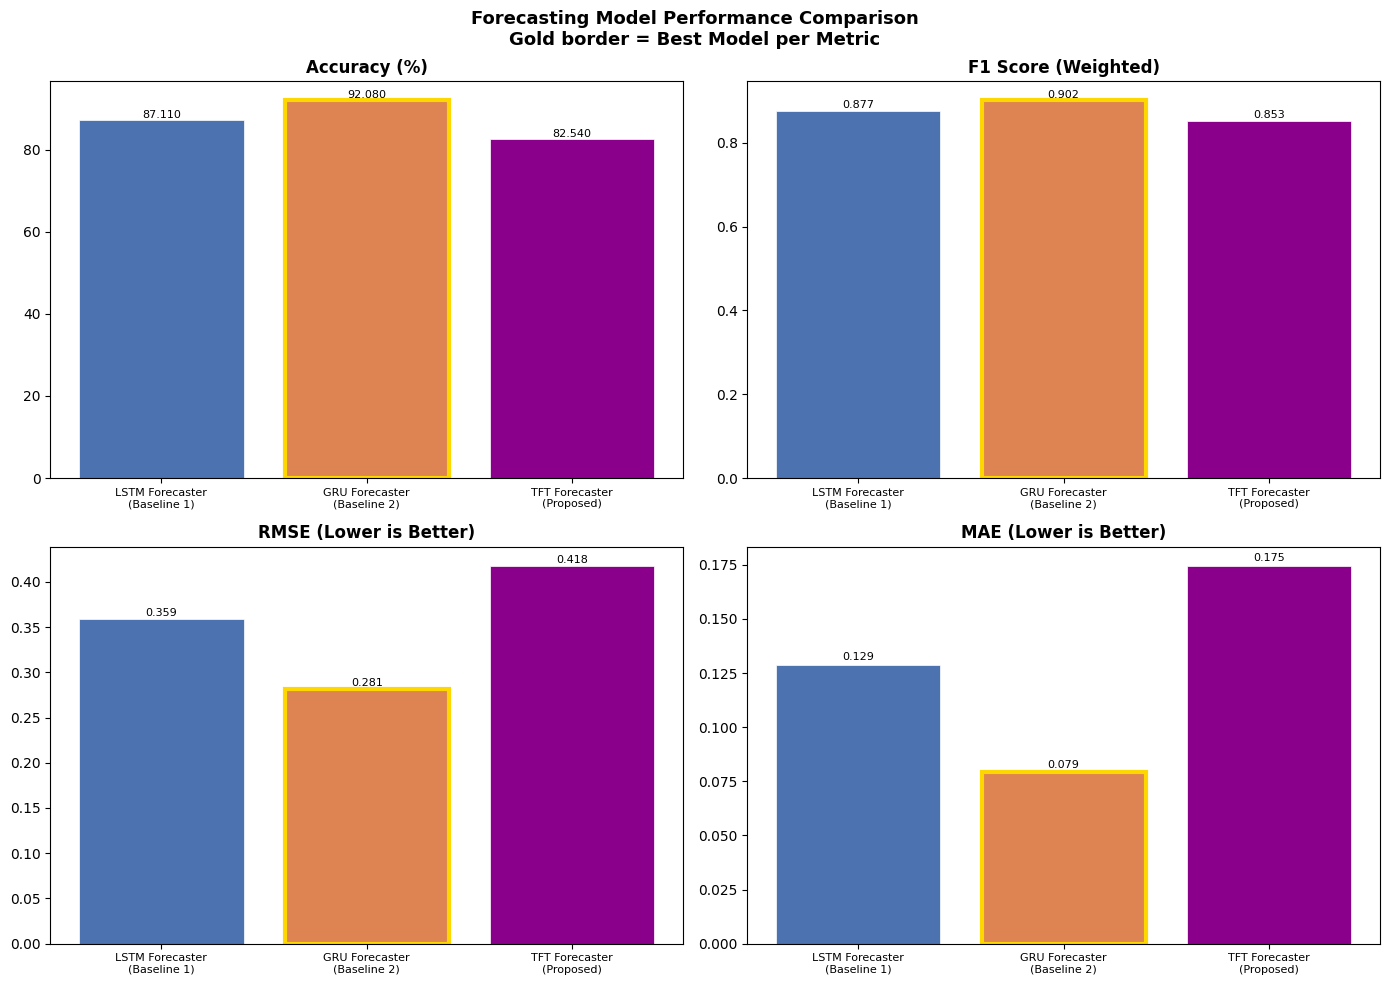

✅ Comparison chart saved.


In [3]:
models  = display_df['Model'].tolist()
colors  = ['#4C72B0','#DD8452','#8B008B']
x       = np.arange(len(models))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [
    ('Accuracy (%)', 'Accuracy (%)', True),
    ('F1 Score',     'F1 Score (Weighted)', True),
    ('RMSE',         'RMSE (Lower is Better)', False),
    ('MAE',          'MAE (Lower is Better)', False),
]

for ax, (col, title, higher_better) in zip(axes.flat, metrics):
    vals = display_df[col].values
    bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' (',  '\n(') for m in models], fontsize=8)
    ax.set_title(title, fontweight='bold')
    best = np.argmax(vals) if higher_better else np.argmin(vals)
    bars[best].set_edgecolor('gold')
    bars[best].set_linewidth(3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Forecasting Model Performance Comparison\nGold border = Best Model per Metric',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved.')


In [4]:
display_df.to_csv('forecast_comparison_results.csv', index=False)
print('✅ Results saved to forecast_comparison_results.csv')


✅ Results saved to forecast_comparison_results.csv
